In [47]:
from datasets import load_dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from collections import Counter
import re
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report

from sklearn.svm import LinearSVC

import copy
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

In [2]:
base = "https://huggingface.co/datasets/Tobi-Bueck/customer-support-tickets/resolve/main/"

files = [
    "aa_dataset-tickets-multi-lang-5-2-50-version.csv",
    "dataset-tickets-multi-lang-4-20k.csv",
    "dataset-tickets-german_normalized_50_5_2.csv",
]

dfs = []

for f in files:
    df_tmp = pd.read_csv(base + f)

    # если нет type ставим Unknown
    if "type" not in df_tmp.columns:
        df_tmp["type"] = "Unknown"

    dfs.append(df_tmp[["subject", "body", "queue", "priority", "type"]])

df = pd.concat(dfs, ignore_index=True)

print(df.shape)
df.head()

(61765, 5)


,subject,body,queue,priority,type
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Technical Support,high,Incident
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high,Incident
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium,Request
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments,low,Request
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales,medium,Problem


In [3]:
df.isna().sum()

,0
subject,5299
body,2
queue,0
priority,0
type,0


In [4]:
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")

In [5]:
df["text"] = df["subject"].str.strip() + " " + df["body"].str.strip()

In [6]:
df.head()

,subject,body,queue,priority,type,text
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Technical Support,high,Incident,Wesentlicher Sicherheitsvorfall Sehr geehrtes ...
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high,Incident,"Account Disruption Dear Customer Support Team,..."
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium,Request,Query About Smart Home System Integration Feat...
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments,low,Request,Inquiry Regarding Invoice Details Dear Custome...
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales,medium,Problem,Question About Marketing Agency Software Compa...


In [7]:
def read_idx(path):
    with open(path) as f:
        return [int(x.strip()) for x in f]

train_idx = read_idx("train_idx.txt")
val_idx   = read_idx("val_idx.txt")
test_idx  = read_idx("test_idx.txt")

In [8]:
train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

In [9]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(49412, 6)
(6176, 6)
(6177, 6)


## EDA

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49412 entries, 0 to 49411
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   49412 non-null  object
 1   body      49412 non-null  object
 2   queue     49412 non-null  object
 3   priority  49412 non-null  object
 4   type      49412 non-null  object
 5   text      49412 non-null  object
dtypes: object(6)
memory usage: 2.3+ MB


In [11]:
print('Классы (queue):', train_df["queue"].nunique())
train_df["queue"].value_counts()

Классы (queue): 52


,count
queue,
Technical Support,11329
Product Support,7159
Customer Service,5901
IT Support,4622
Billing and Payments,3872
Returns and Exchanges,1925
Service Outages and Maintenance,1508
Sales and Pre-Sales,1251
Human Resources,734


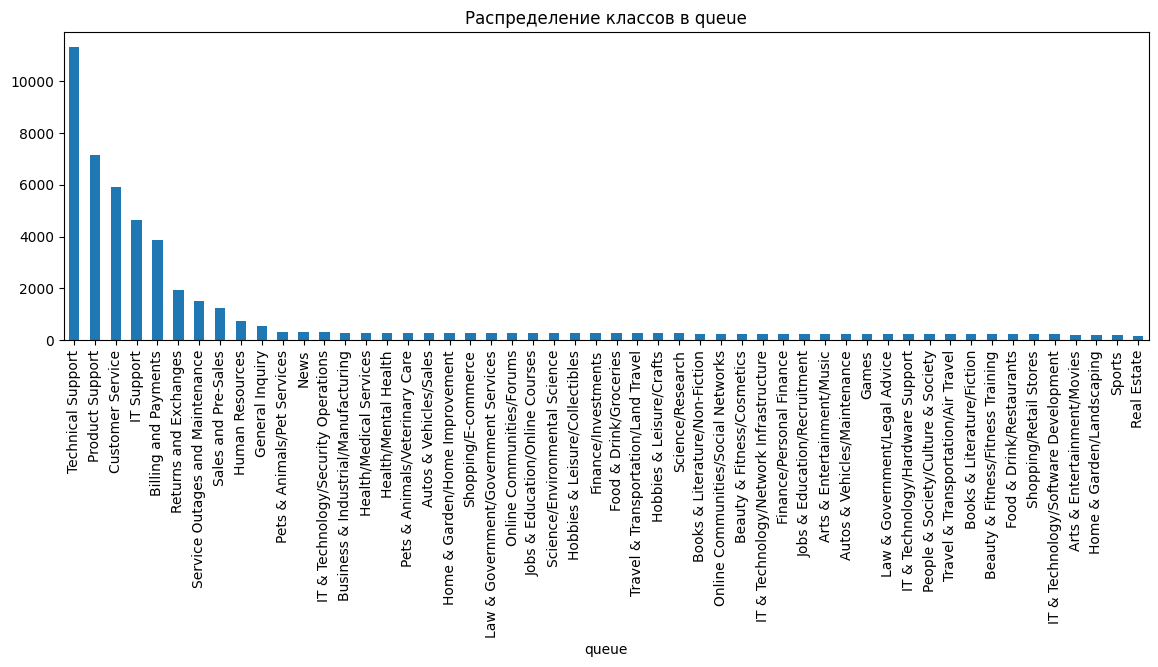

In [12]:
train_df["queue"].value_counts().plot(
    kind="bar",
    figsize=(14,4)
)

plt.title("Распределение классов в queue")
plt.show()

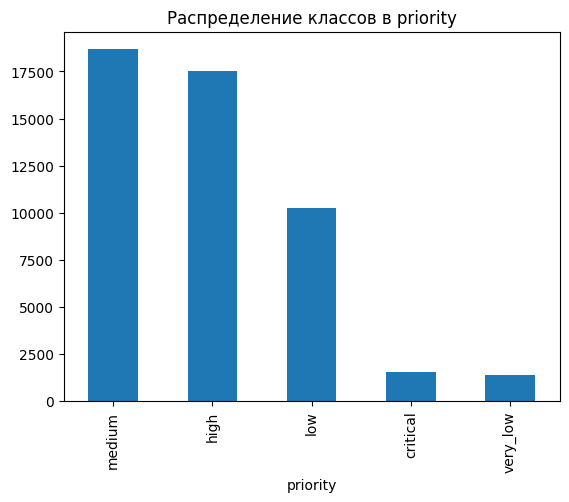

In [13]:
train_df["priority"].value_counts().plot(kind="bar")
plt.title("Распределение классов в priority")
plt.show()

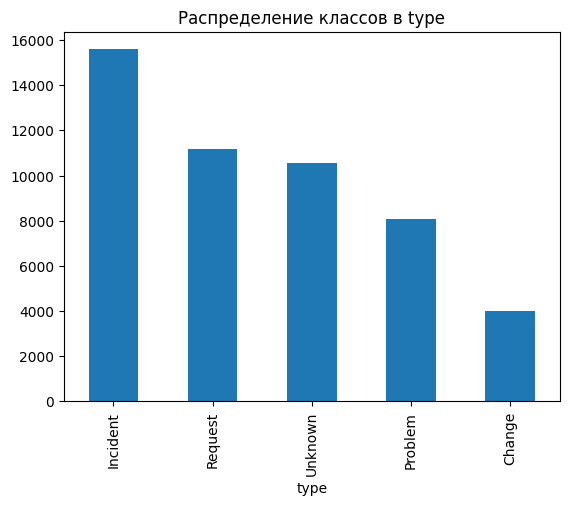

In [14]:
train_df["type"].value_counts().plot(kind="bar")
plt.title("Распределение классов в type")
plt.show()

In [15]:
train_df["text_len"] = train_df["text"].str.len()
train_df["text_len"].describe()

,text_len
count,49412.000000
mean,463.589654
std,226.868935
min,5.000000
25%,278.750000
50%,459.000000
75%,633.000000
max,2284.000000


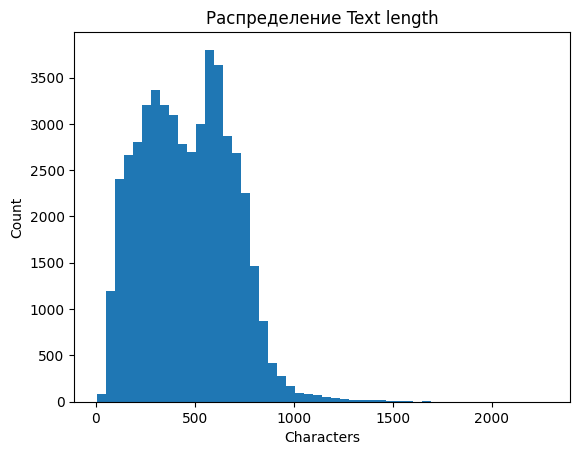

In [16]:
plt.hist(train_df["text_len"], bins=50)
plt.title("Распределение Text length")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()

In [17]:
train_df["subject_len"] = train_df["subject"].str.len()
train_df["body_len"] = train_df["body"].str.len()
train_df[["subject_len","body_len"]].describe()

,subject_len,body_len
count,49412.000000,49412.000000
mean,43.299947,419.291447
std,23.037998,223.688776
min,0.000000,0.000000
25%,31.000000,233.000000
50%,43.000000,415.000000
75%,56.000000,587.000000
max,675.000000,2259.000000


In [18]:
# посмотрим самые частые слова для понимания
words = Counter()

for text in train_df["text"]:
    tokens = re.findall(r"\b\w+\b", text.lower())
    words.update(tokens)

words.most_common(20)

[('the', 70083),
 ('to', 61958),
 ('and', 50351),
 ('die', 45139),
 ('zu', 40350),
 ('und', 39541),
 ('der', 37654),
 ('in', 30070),
 ('problem', 29104),
 ('ich', 26885),
 ('i', 24528),
 ('support', 24468),
 ('data', 23999),
 ('for', 22945),
 ('n', 22674),
 ('you', 22322),
 ('sie', 21284),
 ('um', 20965),
 ('das', 18708),
 ('für', 18209)]

In [19]:
# средние длины текстов по классам
train_df.groupby("queue")["text_len"].mean().sort_values()

,text_len
queue,
Human Resources,407.685286
Returns and Exchanges,421.626494
Product Support,427.069423
IT Support,427.143444
Sales and Pre-Sales,428.631495
Service Outages and Maintenance,429.906499
Technical Support,432.427840
Billing and Payments,436.168130
Customer Service,437.906626


In [20]:
# средние длины текстов по классам
train_df.groupby("priority")["text_len"].mean()

,text_len
priority,
critical,591.025559
high,449.847990
low,466.504825
medium,456.509664
very_low,566.186562


In [21]:
# средние длины текстов по классам
train_df.groupby("type")["text_len"].mean()

,text_len
type,
Change,480.098975
Incident,418.748877
Problem,413.945909
Request,443.560183
Unknown,582.513143


In [22]:
# длинные тексты
train_df.sort_values("text_len", ascending=False).head(5)

,subject,body,queue,priority,type,text,text_len,subject_len,body_len
26590,Rechnungsfehler gemeldet,"Sehr geehrte Kundenservice,\n\nich möchte Ihne...",Billing and Payments,low,Problem,Rechnungsfehler gemeldet Sehr geehrte Kundense...,2284,24,2259
36138,Problem with Inaccurate Invoice,"Dear Customer Support,\n\nI am writing to expr...",Billing and Payments,low,Problem,Problem with Inaccurate Invoice Dear Customer ...,1825,31,1793
26536,Refresh Digital Marketing Strategy for Enhance...,"Dear Customer Support,\n\nI am contacting you ...",Product Support,medium,Change,Refresh Digital Marketing Strategy for Enhance...,1809,60,1748
23348,Support for Integrating Firebase on macOS,"Hello [Your Name],\n\nI hope this message find...",Customer Service,medium,Request,Support for Integrating Firebase on macOS Hell...,1714,41,1672
24999,Inquiry About Analytics Tools for QuickBooks O...,"Hello Customer Support,\n\nI hope this message...",Customer Service,medium,Request,Inquiry About Analytics Tools for QuickBooks O...,1677,75,1601


In [23]:
# длинные тексты
train_df.sort_values("text_len").head(10)

,subject,body,queue,priority,type,text,text_len,subject_len,body_len
23364,,Help,Billing and Payments,medium,Request,Help,5,0,4
18835,,Hallo Support,Customer Service,medium,Change,Hallo Support,14,0,13
26214,,Support needed,Billing and Payments,medium,Incident,Support needed,15,0,14
5722,,Serverprobleme,General Inquiry,medium,Incident,Serverprobleme,15,0,14
23313,,Hello support team,Customer Service,medium,Change,Hello support team,19,0,18
1345,Guidance,Support needed,Billing and Payments,low,Request,Guidance Support needed,23,8,14
3808,,Problems with the server,General Inquiry,medium,Incident,Problems with the server,25,0,24
35651,,Error with Tracking Tools,Returns and Exchanges,low,Incident,Error with Tracking Tools,26,0,25
11723,,Error with Tracking Tools,Returns and Exchanges,low,Incident,Error with Tracking Tools,26,0,25
2690,Technical Issue,Resolve Crash,IT Support,high,Incident,Technical Issue Resolve Crash,29,15,13


In [24]:
# наличие дубликатов
train_df["text"].duplicated().sum()

np.int64(5317)

### Выводы по EDA

Пропусков в данных нет. Все колонки заполнены.

#### Распределение `queue`

По `queue` видно сильный дисбаланс. Несколько категорий сильно доминируют:

- Technical Support ~23%
- Product Support ~14%
- Customer Service ~12%

Получается, что всего **три категории дают почти половину всех данных**.  
При этом у многих других категорий **меньше 300 примеров**. Это типичная ситуация с длинным хвостом классов.


#### Распределение `priority`

По `priority` видно, что больше всего тикетов с приоритетом **medium** и **high**.  
Категории **critical** и **very_low** встречаются сильно реже.

В целом дисбаланс есть, но он не такой сильный, как в `queue`, поэтому задача предсказания `priority` должна быть проще.

#### Распределение `type`

В `type` заметная доля тикетов относится к классу **Unknown** (~21%).  
Это просто означает, что для части тикетов тип изначально не был размечен.

#### Длина текстов

Средняя длина тикета примерно **460 символов**

Примерно так выглядит распределение:

- 25% текстов короче ~280 символов
- половина текстов около ~460 символов
- 75% текстов до ~630 символов

Максимальная длина около **2200 символов**.

В целом большинство тикетов имеют длину **200–700 символов**.

Также встречаются совсем короткие тикеты (5–30 символов), например:

- "Help"
- "Support needed"
- "Server problem"

Но они содержат ключевые слова, которые могут помочь модели

#### Дубликаты

В обучающей выборке нашлось **5317 дубликатов текстов**, это примерно **10.7% данных**.

### Основные наблюдения

Если коротко:

- в `queue` есть **сильный дисбаланс классов**
- тексты в среднем **около 460 символов**
- большинство сообщений имеют длину **200–700 символов**
- есть и **очень короткие тикеты**
- примерно **10% текстов повторяются**


## Предобработка

In [25]:
def preprocess_text(text):
    text = text.lower()

    # убрать переносы строк
    text = re.sub(r"(\\n|\n)+", " ", text)

    # убрать лишние пробелы
    text = re.sub(r"\s+", " ", text)

    # убрать лишние символы
    text = re.sub(r"[^\w\s]", " ", text)

    return text.strip()

In [26]:
train_df["clean_text"] = train_df["text"].apply(preprocess_text)
val_df["clean_text"] = val_df["text"].apply(preprocess_text)
test_df["clean_text"] = test_df["text"].apply(preprocess_text)

In [27]:
train_df[["text", "clean_text"]].head(10)

,text,clean_text
0,Wesentlicher Sicherheitsvorfall Sehr geehrtes ...,wesentlicher sicherheitsvorfall sehr geehrtes ...
1,"Account Disruption Dear Customer Support Team,...",account disruption dear customer support team ...
2,Query About Smart Home System Integration Feat...,query about smart home system integration feat...
3,Inquiry Regarding Invoice Details Dear Custome...,inquiry regarding invoice details dear custome...
4,Question About Marketing Agency Software Compa...,question about marketing agency software compa...
5,"Feature Query Dear Customer Support,\n\nI hope...",feature query dear customer support i hope th...
6,Connectivity Problems with Printer on MacBook ...,connectivity problems with printer on macbook ...
7,Anfrage nach detaillierten Angaben zur Systema...,anfrage nach detaillierten angaben zur systema...
8,Anfrage zur Klärung der Auswirkungen eines Ser...,anfrage zur klärung der auswirkungen eines ser...
9,"VPN Access Issue Customer Support,\n\nWe are e...",vpn access issue customer support we are enco...


## TF-IDF

In [28]:
X_train = train_df["clean_text"]
X_val = val_df["clean_text"]
X_test = test_df["clean_text"]

In [29]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),   # униграммы + биграммы
    min_df=3,             # отсекаем совсем редкие токены
    max_df=0.9,          # отсекаем слишком частые
    sublinear_tf=True,
    token_pattern=r'(?u)\b[a-zA-ZäöüÄÖÜß]{2,}\b'# оставляем только слова (EN + DE), минимум 2 символа
)

In [30]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [31]:
print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Val TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (49412, 125617)
Val TF-IDF shape: (6176, 125617)
Test TF-IDF shape: (6177, 125617)


In [32]:
feature_names = tfidf.get_feature_names_out()
print(feature_names[:50])

['aas' 'ab' 'ab da' 'ab das' 'ab dass' 'ab die' 'ab dies' 'ab ein' 'ab es'
 'ab ich' 'ab möglicherweise' 'ab sehr' 'ab support' 'ab testing' 'ab und'
 'ab vermutlich' 'ab was' 'ab wenn' 'ab wodurch' 'abb' 'abb robotstudio'
 'abbiegehinweise' 'abbruch' 'abbrüche' 'abdecken' 'abdecken und'
 'abdeckt' 'abdeckt einschließlich' 'abdeckt könnten' 'abend' 'abend auf'
 'abend begann' 'abend gegen' 'abend hat' 'abend und' 'aber' 'aber als'
 'aber auch' 'aber auf' 'aber aufgrund' 'aber begrüßen' 'aber bereits'
 'aber besorgt' 'aber bestimmte' 'aber bisher' 'aber bislang'
 'aber dankbar' 'aber darauf' 'aber das' 'aber dass']


In [33]:
print(feature_names[:20])
print(feature_names[-20:])

['aas' 'ab' 'ab da' 'ab das' 'ab dass' 'ab die' 'ab dies' 'ab ein' 'ab es'
 'ab ich' 'ab möglicherweise' 'ab sehr' 'ab support' 'ab testing' 'ab und'
 'ab vermutlich' 'ab was' 'ab wenn' 'ab wodurch' 'abb']
['überweisungen' 'überweisungen support' 'überweisungen und'
 'überweisungsanfragen' 'überweisungsstatus' 'überwinden'
 'überwinden bitte' 'überwinden wir' 'überwältigend' 'überzeugt'
 'überzeugt dass' 'überzeugung' 'überzeugung dass' 'üblich' 'übliche'
 'üblichen' 'üblichen tage' 'üblichen zeitrahmens' 'übungen' 'übungen zu']


In [34]:
total_cells = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
non_zero = X_train_tfidf.nnz

print("Non-zero elements:", non_zero)
print("Sparsity:", 1 - non_zero / total_cells)

Non-zero elements: 5052422
Sparsity: 0.9991860105661658


## Модели
### Модель для `queue`

In [35]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier

y_train_queue = train_df["queue"].astype(str)
y_val_queue = val_df["queue"].astype(str)
y_test_queue = test_df["queue"].astype(str)

def evaluate_baseline_models(models, X_train_vec, y_train, X_val_vec, y_val, metric_name="macro_f1"):
    rows = []
    fitted_models = {}

    for model_name, model in models.items():
        model.fit(X_train_vec, y_train)
        pred_val = model.predict(X_val_vec)

        if metric_name == "macro_f1":
            score = f1_score(y_val, pred_val, average="macro")
        else:
            score = accuracy_score(y_val, pred_val)

        rows.append({"model": model_name, metric_name: score})
        fitted_models[model_name] = model

    results_df = pd.DataFrame(rows).sort_values(metric_name, ascending=False).reset_index(drop=True)
    best_model_name = results_df.loc[0, "model"]
    best_model = fitted_models[best_model_name]

    return best_model, results_df


In [36]:
queue_models = {
    "LinearSVC(C=10)": LinearSVC(C=10),
    "LogisticRegression(C=6)": LogisticRegression(C=6, max_iter=3000, solver="lbfgs"),
    "SGDClassifier(hinge)": SGDClassifier(loss="hinge", alpha=1e-5, max_iter=2000, random_state=42),
    "MultinomialNB(alpha=0.3)": MultinomialNB(alpha=0.3),
}

model_queue_svc, queue_model_results = evaluate_baseline_models(
    models=queue_models,
    X_train_vec=X_train_tfidf,
    y_train=y_train_queue,
    X_val_vec=X_val_tfidf,
    y_val=y_val_queue,
    metric_name="macro_f1",
)

display(queue_model_results)

pred_queue_val_svc = model_queue_svc.predict(X_val_tfidf)
f1_score_queue = f1_score(y_val_queue, pred_queue_val_svc, average="macro")

print("Best queue model:", queue_model_results.loc[0, "model"])
print("Queue Macro-F1 (val):", f1_score_queue)

,model,macro_f1
0,LinearSVC(C=10),0.922217
1,SGDClassifier(hinge),0.906677
2,LogisticRegression(C=6),0.876978
3,MultinomialNB(alpha=0.3),0.688732


Best queue model: LinearSVC(C=10)
Queue Macro-F1 (val): 0.9222167545252578


### Модель для `priority`

In [37]:
y_train_priority = train_df["priority"].astype(str)
y_val_priority = val_df["priority"].astype(str)
y_test_priority = test_df["priority"].astype(str)

In [38]:
priority_models = {
    "LinearSVC(C=5)": LinearSVC(C=5),
    "LogisticRegression(C=4)": LogisticRegression(C=4, max_iter=3000, solver="lbfgs"),
    "SGDClassifier(log_loss)": SGDClassifier(loss="log_loss", alpha=1e-5, max_iter=2000, random_state=42),
    "MultinomialNB(alpha=0.2)": MultinomialNB(alpha=0.2),
}

model_priority_svc, priority_model_results = evaluate_baseline_models(
    models=priority_models,
    X_train_vec=X_train_tfidf,
    y_train=y_train_priority,
    X_val_vec=X_val_tfidf,
    y_val=y_val_priority,
    metric_name="acc",
)

display(priority_model_results)

pred_priority_val_svc = model_priority_svc.predict(X_val_tfidf)
acc_priority_val_svc = accuracy_score(y_val_priority, pred_priority_val_svc)

print("Best priority model:", priority_model_results.loc[0, "model"])
print("Priority Accuracy (val):", acc_priority_val_svc)

,model,acc
0,LinearSVC(C=5),0.787079
1,LogisticRegression(C=4),0.756315
2,SGDClassifier(log_loss),0.711464
3,MultinomialNB(alpha=0.2),0.612047


Best priority model: LinearSVC(C=5)
Priority Accuracy (val): 0.7870790155440415


### Модель для `type`

In [39]:
y_train_type = train_df["type"].fillna("Unknown").astype(str)
y_val_type = val_df["type"].fillna("Unknown").astype(str)
y_test_type = test_df["type"].fillna("Unknown").astype(str)

In [40]:
type_models = {
    "LinearSVC(C=4)": LinearSVC(C=4),
    "LogisticRegression(C=4)": LogisticRegression(C=4, max_iter=3000, solver="lbfgs"),
    "SGDClassifier(log_loss)": SGDClassifier(loss="log_loss", alpha=1e-5, max_iter=2000, random_state=42),
    "MultinomialNB(alpha=0.15)": MultinomialNB(alpha=0.15),
}

model_type_svc, type_model_results = evaluate_baseline_models(
    models=type_models,
    X_train_vec=X_train_tfidf,
    y_train=y_train_type,
    X_val_vec=X_val_tfidf,
    y_val=y_val_type,
    metric_name="acc",
)

display(type_model_results)

pred_type_val = model_type_svc.predict(X_val_tfidf)
acc_type_val = accuracy_score(y_val_type, pred_type_val)

print("Best type model:", type_model_results.loc[0, "model"])
print("Type Accuracy (val):", acc_type_val)

,model,acc
0,LinearSVC(C=4),0.920984
1,LogisticRegression(C=4),0.912727
2,SGDClassifier(log_loss),0.896697
3,MultinomialNB(alpha=0.15),0.867228


Best type model: LinearSVC(C=4)
Type Accuracy (val): 0.9209844559585493


## Итоговая метрика

In [41]:
pred_queue_test = model_queue_svc.predict(X_test_tfidf)
f1_score_queue_test = f1_score(y_test_queue, pred_queue_test, average="macro")

pred_priority_test = model_priority_svc.predict(X_test_tfidf)
acc_priority_test = accuracy_score(y_test_priority, pred_priority_test)

pred_type_test = model_type_svc.predict(X_test_tfidf)
acc_type_test = accuracy_score(y_test_type, pred_type_test)

macro_f1_queue = f1_score_queue_test
acc_priority = acc_priority_test
acc_type = acc_type_test

score = (
    0.70 * macro_f1_queue +
    0.15 * acc_priority +
    0.15 * acc_type
)

baseline_summary = pd.DataFrame({
    "task": ["queue", "priority", "type"],
    "best_model": [
        queue_model_results.loc[0, "model"],
        priority_model_results.loc[0, "model"],
        type_model_results.loc[0, "model"],
    ],
    "val_metric": [f1_score_queue, acc_priority_val_svc, acc_type_val],
    "test_metric": [f1_score_queue_test, acc_priority_test, acc_type_test],
})

display(baseline_summary)
print("Final baseline score (test):", score)


,task,best_model,val_metric,test_metric
0,queue,LinearSVC(C=10),0.922217,0.920280
1,priority,LinearSVC(C=5),0.787079,0.785333
2,type,LinearSVC(C=4),0.920984,0.919055


Final baseline score (test): 0.8998541907806638


## Confidence

In [45]:
def evaluate_confidence_coverage(
        model,
        X,
        y_true,
        fractions=None,
        title="Confidence coverage analysis"
):

    if fractions is None:
        fractions = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4]

    # предсказания
    y_pred = model.predict(X)

    # confidence
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
    elif hasattr(model, "predict_proba"):
        scores = model.predict_proba(X)
    else:
        raise ValueError("У модели нет ни decision_function, ни predict_proba")

    # на случай бинарной классификации
    if scores.ndim == 1:
        confidence = np.abs(scores)
    else:
        sorted_scores = np.sort(scores, axis=1)
        confidence = sorted_scores[:, -1] - sorted_scores[:, -2]

    details_df = pd.DataFrame({
        "y_true": y_true.values if hasattr(y_true, "values") else y_true,
        "y_pred": y_pred,
        "confidence": confidence
    }).sort_values("confidence", ascending=False).reset_index(drop=True)

    results = []
    n = len(details_df)

    for frac in fractions:
        k = max(1, int(n * frac))
        subset = details_df.iloc[:k]

        macro_f1 = f1_score(subset["y_true"], subset["y_pred"], average="macro")
        acc = accuracy_score(subset["y_true"], subset["y_pred"])

        results.append({
            "coverage": frac,
            "coverage_pct": int(frac * 100),
            "manual_share": 1 - frac,
            "manual_pct": int((1 - frac) * 100),
            "n_samples": k,
            "macro_f1": macro_f1,
            "accuracy": acc
        })

    results_df = pd.DataFrame(results)

    # прирост относительно 100%
    full_macro_f1 = results_df.loc[results_df["coverage"] == 1.0, "macro_f1"].values[0]
    full_acc = results_df.loc[results_df["coverage"] == 1.0, "accuracy"].values[0]

    results_df["macro_f1_gain_vs_full"] = results_df["macro_f1"] - full_macro_f1
    results_df["accuracy_gain_vs_full"] = results_df["accuracy"] - full_acc

    # график
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["coverage_pct"], results_df["macro_f1"], marker="o", label="Macro-F1")
    plt.plot(results_df["coverage_pct"], results_df["accuracy"], marker="o", label="Accuracy")
    plt.gca().invert_xaxis()
    plt.xlabel("Доля автоматически обработанных тикетов, %")
    plt.ylabel("Метрика")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

    return results_df, details_df

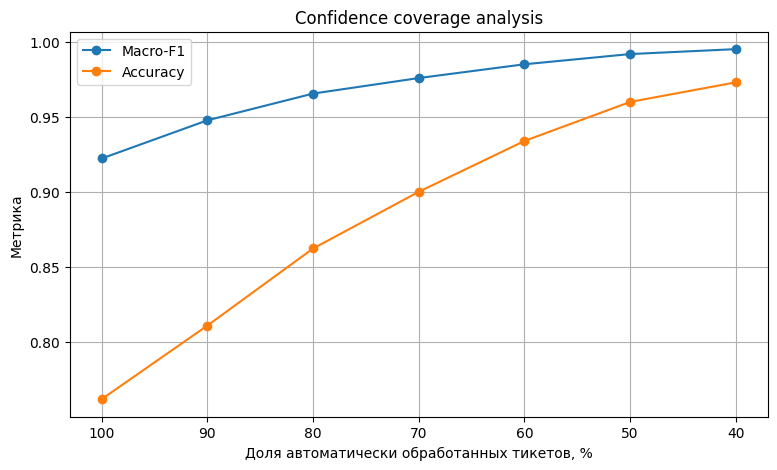

,coverage,coverage_pct,manual_share,manual_pct,n_samples,macro_f1,accuracy,macro_f1_gain_vs_full,accuracy_gain_vs_full
0,1.0,100,0.0,0,6176,0.922217,0.762144,0.000000,0.000000
1,0.9,90,0.1,9,5558,0.947622,0.811083,0.025405,0.048939
2,0.8,80,0.2,19,4940,0.965402,0.862348,0.043185,0.100204
3,0.7,70,0.3,30,4323,0.975731,0.900069,0.053514,0.137926
4,0.6,60,0.4,40,3705,0.984891,0.933873,0.062674,0.171729
5,0.5,50,0.5,50,3088,0.991685,0.959845,0.069469,0.197701
6,0.4,40,0.6,60,2470,0.994968,0.972874,0.072751,0.210731


In [48]:
queue_conf_results, queue_conf_df = evaluate_confidence_coverage(
    model=model_queue_svc,
    X=X_val_tfidf,
    y_true=y_val_queue
)

queue_conf_results

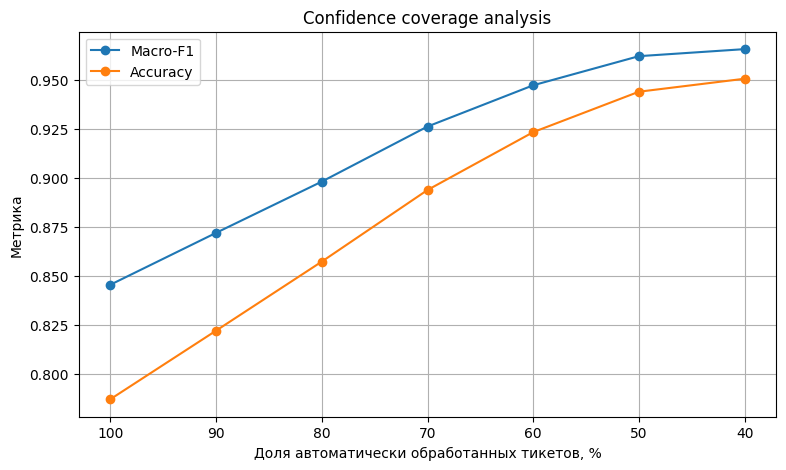

,coverage,coverage_pct,manual_share,manual_pct,n_samples,macro_f1,accuracy,macro_f1_gain_vs_full,accuracy_gain_vs_full
0,1.0,100,0.0,0,6176,0.845503,0.787079,0.000000,0.000000
1,0.9,90,0.1,9,5558,0.871968,0.822058,0.026465,0.034979
2,0.8,80,0.2,19,4940,0.898119,0.857287,0.052615,0.070208
3,0.7,70,0.3,30,4323,0.926215,0.893824,0.080711,0.106745
4,0.6,60,0.4,40,3705,0.947268,0.923347,0.101765,0.136268
5,0.5,50,0.5,50,3088,0.962125,0.943977,0.116622,0.156898
6,0.4,40,0.6,60,2470,0.965717,0.950607,0.120214,0.163528


In [49]:
priority_conf_results, priority_conf_df = evaluate_confidence_coverage(
    model=model_priority_svc,
    X=X_val_tfidf,
    y_true=y_val_priority
)

priority_conf_results

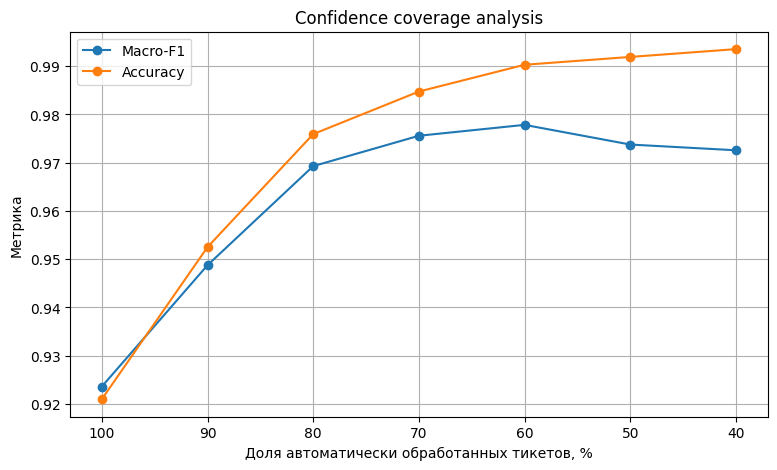

,coverage,coverage_pct,manual_share,manual_pct,n_samples,macro_f1,accuracy,macro_f1_gain_vs_full,accuracy_gain_vs_full
0,1.0,100,0.0,0,6176,0.923595,0.920984,0.000000,0.000000
1,0.9,90,0.1,9,5558,0.948746,0.952501,0.025152,0.031516
2,0.8,80,0.2,19,4940,0.969273,0.975911,0.045678,0.054926
3,0.7,70,0.3,30,4323,0.975570,0.984733,0.051975,0.063748
4,0.6,60,0.4,40,3705,0.977825,0.990283,0.054231,0.069299
5,0.5,50,0.5,50,3088,0.973747,0.991904,0.050152,0.070920
6,0.4,40,0.6,60,2470,0.972559,0.993522,0.048964,0.072538


In [50]:
type_conf_results, type_conf_df = evaluate_confidence_coverage(
    model=model_type_svc,
    X=X_val_tfidf,
    y_true=y_val_type
)

type_conf_results

### Выводы confidence-анализа

Мы посмотрели, как меняется качество модели, если учитывать только те предсказания, в которых модель наиболее уверена. Идея в том, что часть тикетов модель классифицирует очень уверенно, а часть с сомнениями. Поэтому можно проверить, что будет, если автоматически обрабатывать только самые уверенные случаи

Для задачи `queue` видно, что модель и так работает довольно хорошо (Macro-F1 около 0.92 на всей валидации), но если брать только *70% самых уверенных тикетов*, метрика поднимается примерно до *0.97–0.98*. Это означает, что большая часть ошибок приходится на наименее уверенные предсказания

Похожая картина наблюдается и для `priority`: accuracy заметно растет, если смотреть только на уверенные предсказания. Это говорит о том, что модель достаточно хорошо понимает, когда она *знает ответ*, а когда сомневается

Для `type` ситуация немного интереснее: метрика растет примерно до *60–70% coverage*, а затем немного снижается. Скорее всего это связано с тем, что при слишком сильном отборе остается уже довольно маленькая выборка, и на ней метрика становится менее стабильной. То есть падение после 60% не означает, что модель начинает работать хуже, просто оценка становится более шумной из-за уменьшения количества примеров

В целом результаты показывают, что модель особенно надежна на наиболее уверенных предсказаниях. Это означает, что в реальной системе можно было бы автоматически обрабатывать большую часть тикетов, а оставшиеся наиболее сомнительные случаи (например 20–30%) отправлять на ручную проверку

## Transformer / Multi-task

In [42]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

class TicketMultiTaskDataset(Dataset):
    def __init__(self, df, tokenizer, queue2id, priority2id, type2id, text_col="text", max_length=64):
        self.texts = df[text_col].astype(str).tolist()
        self.queue = df["queue"].astype(str).map(queue2id).astype(int).tolist()
        self.priority = df["priority"].astype(str).map(priority2id).astype(int).tolist()
        self.type = df["type"].fillna("Unknown").astype(str).map(type2id).astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding=False,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels_queue"] = torch.tensor(self.queue[idx], dtype=torch.long)
        item["labels_priority"] = torch.tensor(self.priority[idx], dtype=torch.long)
        item["labels_type"] = torch.tensor(self.type[idx], dtype=torch.long)
        return item

def multitask_collate(batch, tokenizer):
    pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    max_len = max(x["input_ids"].shape[0] for x in batch)

    input_ids, attention_mask = [], []
    labels_queue, labels_priority, labels_type = [], [], []

    for x in batch:
        cur_len = x["input_ids"].shape[0]
        pad_len = max_len - cur_len

        input_ids.append(torch.cat([x["input_ids"], torch.full((pad_len,), pad_token_id, dtype=torch.long)]))
        attention_mask.append(torch.cat([x["attention_mask"], torch.zeros(pad_len, dtype=torch.long)]))
        labels_queue.append(x["labels_queue"])
        labels_priority.append(x["labels_priority"])
        labels_type.append(x["labels_type"])

    return {
        "input_ids": torch.stack(input_ids),
        "attention_mask": torch.stack(attention_mask),
        "labels_queue": torch.stack(labels_queue),
        "labels_priority": torch.stack(labels_priority),
        "labels_type": torch.stack(labels_type),
    }

def make_label_maps(train_df, val_df, test_df):
    queue_labels = sorted(set(train_df["queue"].astype(str)) | set(val_df["queue"].astype(str)) | set(test_df["queue"].astype(str)))
    priority_labels = sorted(set(train_df["priority"].astype(str)) | set(val_df["priority"].astype(str)) | set(test_df["priority"].astype(str)))
    type_labels = sorted(set(train_df["type"].fillna("Unknown").astype(str)) | set(val_df["type"].fillna("Unknown").astype(str)) | set(test_df["type"].fillna("Unknown").astype(str)))

    queue2id = {label: i for i, label in enumerate(queue_labels)}
    priority2id = {label: i for i, label in enumerate(priority_labels)}
    type2id = {label: i for i, label in enumerate(type_labels)}
    return queue2id, priority2id, type2id

class DistilBertMultiTask(nn.Module):
    def __init__(self, model_name, num_queue_labels, num_priority_labels, num_type_labels, dropout=0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.queue_head = nn.Linear(hidden_size, num_queue_labels)
        self.priority_head = nn.Linear(hidden_size, num_priority_labels)
        self.type_head = nn.Linear(hidden_size, num_type_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_repr = self.dropout(outputs.last_hidden_state[:, 0])
        return (
            self.queue_head(cls_repr),
            self.priority_head(cls_repr),
            self.type_head(cls_repr),
        )

def evaluate_multitask(model, loader, device):
    model.eval()

    y_true_queue, y_pred_queue = [], []
    y_true_priority, y_pred_priority = [], []
    y_true_type, y_pred_type = [], []

    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits_queue, logits_priority, logits_type = model(input_ids=input_ids, attention_mask=attention_mask)

            y_pred_queue.extend(logits_queue.argmax(dim=1).cpu().numpy())
            y_pred_priority.extend(logits_priority.argmax(dim=1).cpu().numpy())
            y_pred_type.extend(logits_type.argmax(dim=1).cpu().numpy())

            y_true_queue.extend(batch["labels_queue"].numpy())
            y_true_priority.extend(batch["labels_priority"].numpy())
            y_true_type.extend(batch["labels_type"].numpy())

    queue_macro_f1 = f1_score(y_true_queue, y_pred_queue, average="macro")
    queue_acc = accuracy_score(y_true_queue, y_pred_queue)
    priority_acc = accuracy_score(y_true_priority, y_pred_priority)
    type_acc = accuracy_score(y_true_type, y_pred_type)
    final_score_mt = 0.70 * queue_macro_f1 + 0.15 * priority_acc + 0.15 * type_acc

    return {
        "queue_macro_f1": queue_macro_f1,
        "queue_acc": queue_acc,
        "priority_acc": priority_acc,
        "type_acc": type_acc,
        "final_score": final_score_mt,
    }

def train_multitask_transformer(
    train_df,
    val_df,
    test_df,
    model_name="distilbert-base-multilingual-cased",
    text_col="text",
    lr=3e-5,
    batch_size=8,
    epochs=1,
    max_length=64,
    loss_weights=(0.70, 0.15, 0.15),
    use_subset=False,
    subset_size=12000,
):
    if use_subset:
        train_used = train_df.sample(min(subset_size, len(train_df)), random_state=42).reset_index(drop=True)
    else:
        train_used = train_df.reset_index(drop=True)

    val_used = val_df.reset_index(drop=True)
    test_used = test_df.reset_index(drop=True)

    queue2id, priority2id, type2id = make_label_maps(train_used, val_used, test_used)
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_dataset = TicketMultiTaskDataset(train_used, tokenizer, queue2id, priority2id, type2id, text_col=text_col, max_length=max_length)
    val_dataset = TicketMultiTaskDataset(val_used, tokenizer, queue2id, priority2id, type2id, text_col=text_col, max_length=max_length)
    test_dataset = TicketMultiTaskDataset(test_used, tokenizer, queue2id, priority2id, type2id, text_col=text_col, max_length=max_length)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=lambda batch: multitask_collate(batch, tokenizer))
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=lambda batch: multitask_collate(batch, tokenizer))
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=lambda batch: multitask_collate(batch, tokenizer))

    model = DistilBertMultiTask(
        model_name=model_name,
        num_queue_labels=len(queue2id),
        num_priority_labels=len(priority2id),
        num_type_labels=len(type2id),
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    ce_loss = nn.CrossEntropyLoss()

    best_val_score = -1
    best_state = None
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels_queue = batch["labels_queue"].to(DEVICE)
            labels_priority = batch["labels_priority"].to(DEVICE)
            labels_type = batch["labels_type"].to(DEVICE)

            logits_queue, logits_priority, logits_type = model(input_ids=input_ids, attention_mask=attention_mask)

            loss_queue = ce_loss(logits_queue, labels_queue)
            loss_priority = ce_loss(logits_priority, labels_priority)
            loss_type = ce_loss(logits_type, labels_type)

            loss = (
                loss_weights[0] * loss_queue +
                loss_weights[1] * loss_priority +
                loss_weights[2] * loss_type
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        val_metrics = evaluate_multitask(model, val_loader, DEVICE)

        epoch_row = {
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            **val_metrics,
        }
        history.append(epoch_row)
        print(epoch_row)

        if val_metrics["final_score"] > best_val_score:
            best_val_score = val_metrics["final_score"]
            best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate_multitask(model, test_loader, DEVICE)
    history_df = pd.DataFrame(history)

    return model, history_df, test_metrics

Device: cuda


In [43]:
multitask_configs = [
    {"model_name": "distilbert-base-multilingual-cased", "lr": 3e-5, "batch_size": 8, "epochs": 1, "max_length": 64},
    {"model_name": "distilbert-base-multilingual-cased", "lr": 3e-5, "batch_size": 8, "epochs": 2, "max_length": 64},
]

multitask_runs = []
best_multitask = None
best_multitask_score = -1

for cfg in multitask_configs:
    _, history_df, test_metrics = train_multitask_transformer(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        model_name=cfg["model_name"],
        text_col="text",
        lr=cfg["lr"],
        batch_size=cfg["batch_size"],
        epochs=cfg["epochs"],
        max_length=cfg["max_length"],
        loss_weights=(0.70, 0.15, 0.15),
        use_subset=False,
    )

    best_epoch_idx = history_df["final_score"].idxmax()
    row = {
        **cfg,
        "best_val_final_score": history_df.loc[best_epoch_idx, "final_score"],
        "best_val_queue_macro_f1": history_df.loc[best_epoch_idx, "queue_macro_f1"],
        "test_final_score": test_metrics["final_score"],
        "test_queue_macro_f1": test_metrics["queue_macro_f1"],
        "test_priority_acc": test_metrics["priority_acc"],
        "test_type_acc": test_metrics["type_acc"],
    }
    multitask_runs.append(row)
    print(row)

    if row["best_val_final_score"] > best_multitask_score:
        best_multitask_score = row["best_val_final_score"]
        best_multitask = row

multitask_results_df = pd.DataFrame(multitask_runs).sort_values("best_val_final_score", ascending=False).reset_index(drop=True)
display(multitask_results_df)
print("Best multitask config:", best_multitask)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

{'epoch': 2, 'train_loss': 1.0506596490463354, 'queue_macro_f1': 0.8210120265114605, 'queue_acc': 0.5871113989637305, 'priority_acc': 0.5446891191709845, 'type_acc': 0.8416450777202072, 'final_score': 0.7826585480917011}


  0%|          | 0/773 [00:00<?, ?it/s]

{'model_name': 'distilbert-base-multilingual-cased', 'lr': 3e-05, 'batch_size': 8, 'epochs': 2, 'max_length': 64, 'best_val_final_score': np.float64(0.7826585480917011), 'best_val_queue_macro_f1': np.float64(0.8210120265114605), 'test_final_score': 0.7838891116169995, 'test_queue_macro_f1': 0.822436467646848, 'test_priority_acc': 0.5530192650153797, 'test_type_acc': 0.8348712967459933}


,model_name,lr,batch_size,epochs,max_length,best_val_final_score,best_val_queue_macro_f1,test_final_score,test_queue_macro_f1,test_priority_acc,test_type_acc
0,distilbert-base-multilingual-cased,0.00003,8,2,64,0.782659,0.821012,0.783889,0.822436,0.553019,0.834871
1,distilbert-base-multilingual-cased,0.00003,8,1,64,0.701915,0.721799,0.704133,0.723555,0.507366,0.810264


Best multitask config: {'model_name': 'distilbert-base-multilingual-cased', 'lr': 3e-05, 'batch_size': 8, 'epochs': 2, 'max_length': 64, 'best_val_final_score': np.float64(0.7826585480917011), 'best_val_queue_macro_f1': np.float64(0.8210120265114605), 'test_final_score': 0.7838891116169995, 'test_queue_macro_f1': 0.822436467646848, 'test_priority_acc': 0.5530192650153797, 'test_type_acc': 0.8348712967459933}


In [44]:
comparison_df = pd.DataFrame({
    "approach": ["Best baseline", "Best multitask transformer"],
    "val_metric": [0.70 * f1_score_queue + 0.15 * acc_priority_val_svc + 0.15 * acc_type_val, multitask_results_df.loc[0, "best_val_final_score"]],
    "test_metric": [score, multitask_results_df.loc[0, "test_final_score"]],
})

display(comparison_df)
print("Baseline final score (test):", score)
print("Best multitask transformer final score (test):", multitask_results_df.loc[0, "test_final_score"])


,approach,val_metric,test_metric
0,Best baseline,0.901761,0.899854
1,Best multitask transformer,0.782659,0.783889


Baseline final score (test): 0.8998541907806638
Best multitask transformer final score (test): 0.7838891116169995


Несмотря на то, что мультитаск-трансформер был добавлен в качестве более сложного подхода, тут он показал заметно более слабые результаты по сравнению с классическим baseline на основе TF-IDF и линейных моделей. Поэтому далее смотрим только на лучшую базовую модель